# UniProtKB Parquet Data Lake Demo

This notebook demonstrates querying the UniProtKB Parquet data lake using **DuckDB**, **Polars**, **pandas**, and **PyArrow**.

The demo dataset contains **~3,800 reviewed _Drosophila melanogaster_ proteins** — small enough to run on a laptop, large enough to show real query patterns.

### Data model

Five sorted Parquet tables, all sharing `(acc, taxid)` as join keys:

| Table | Description | Key columns |
|-------|-------------|-------------|
| **entries** | One row per protein | `acc`, `reviewed`, `taxid`, `gene_name`, `protein_name`, `sequence`, `seq_length`, ... |
| **features** | One row per positional annotation | `acc`, `type`, `start_pos`, `end_pos`, `description`, ... |
| **xrefs** | One row per cross-reference | `acc`, `database`, `id`, `properties`, ... |
| **comments** | One row per comment | `acc`, `comment_type`, `text_value`, ... |
| **references** | One row per citation | `acc`, `citation_type`, `title`, `authors`, ... |

Each table has two layers: **flattened convenience columns** for simple SQL, and **full nested structs** for lossless access to the original UniProtKB JSON.

## 1. Setup

In [1]:
import os
import sys
import json

# Path to the demo lake (built by run_demo.sh)
LAKE = os.path.join(os.getcwd(), "lake", "2026_01", "lake")
assert os.path.exists(LAKE), f"Lake not found at {LAKE} — run ./run_demo.sh first"

# Add project root so we can import uniprot_lake.py
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

# Quick inventory
with open(os.path.join(LAKE, "manifest.json")) as f:
    manifest = json.load(f)

print(f"Release: {manifest['release']}")
print(f"Total rows: {manifest['total_rows']:,}")
print()
for name, info in manifest["tables"].items():
    print(f"  {name:12s}  {info['row_count']:>10,} rows  ({len(info['files'])} files)")

Release: 2026_01
Total rows: 374,964

  entries            3,868 rows  (1 files)
  features          70,141 rows  (1 files)
  xrefs            254,073 rows  (1 files)
  comments          23,119 rows  (1 files)
  references        23,763 rows  (1 files)


## 2. DuckDB — SQL queries with views and macros

The `uniprot_lake.connect()` one-liner sets up five views (`entries`, `features`, `xrefs`, `comments`, `refs`) and six macros. No globs or boilerplate needed.

In [2]:
from uniprot_lake import connect, schema

con = connect(LAKE)
print("Connected. Available views and macros are ready.")

Connected. Available views and macros are ready.


### Explore the schema

In [3]:
# Overview of all tables — descriptions, row counts, keys, join hints
overview = schema(LAKE)
for name, info in overview.items():
    print(f"\n{name}:")
    for k, v in info.items():
        print(f"  {k}: {v}")


entries:
  description: One row per protein. Primary table for most queries.
  row_count: 3868
  primary_key: ['acc']
  sort_order: ['reviewed DESC', 'taxid ASC', 'acc ASC']

features:
  description: One row per positional annotation (domain, signal, transmembrane, etc). Sorted by start_pos within each protein.
  row_count: 70141
  primary_key: []
  sort_order: ['from_reviewed DESC', 'taxid ASC', 'acc ASC', 'start_pos ASC']
  foreign_keys: {'acc': 'entries.acc', 'taxid': 'entries.taxid'}
  join_hint: JOIN features USING (acc, taxid)

xrefs:
  description: One row per cross-reference to an external database (PDB, Ensembl, GO, InterPro, etc).
  row_count: 254073
  primary_key: []
  sort_order: ['from_reviewed DESC', 'taxid ASC', 'acc ASC', 'database ASC']
  foreign_keys: {'acc': 'entries.acc', 'taxid': 'entries.taxid'}
  join_hint: JOIN xrefs USING (acc, taxid)

comments:
  description: One row per comment annotation (function, subcellular location, disease, etc).
  row_count: 23119
  p

In [4]:
# Detailed column list for the entries table
# (Nested struct types are truncated for readability)
con.sql("""
    SELECT
        column_name,
        CASE
            WHEN length(column_type) > 40
            THEN column_type[:37] || '...'
            ELSE column_type
        END AS column_type,
        "null",
        key,
        "default",
        extra
    FROM (DESCRIBE entries)
""").df()

,column_name,column_type,null,key,default,extra
0,acc,VARCHAR,YES,None,None,None
1,id,VARCHAR,YES,None,None,None
2,reviewed,BOOLEAN,YES,None,None,None
3,secondary_accs,VARCHAR[],YES,None,None,None
4,taxid,BIGINT,YES,None,None,None
5,organism_name,VARCHAR,YES,None,None,None
6,organism_common,VARCHAR,YES,None,None,None
7,lineage,VARCHAR[],YES,None,None,None
8,gene_name,VARCHAR,YES,None,None,None
9,gene_synonyms,VARCHAR[],YES,None,None,None


### Basic queries

In [5]:
# Top 10 proteins by sequence length
con.sql("""
    SELECT acc, gene_name, protein_name, seq_length, annotation_score
    FROM entries
    ORDER BY seq_length DESC
    LIMIT 10
""").df()

,acc,gene_name,protein_name,seq_length,annotation_score
0,Q9I7U4,sls,Titin,18141,5.0
1,M9MRD1,Msp300,Muscle-specific protein 300 kDa,12345,5.0
2,Q8SX83,spen,Protein split ends,5560,5.0
3,Q9W596,futsch,Microtubule-associated protein futsch,5495,5.0
4,Q9VLT5,poe,Protein purity of essence,5322,5.0
5,Q9NB71,hiw,E3 ubiquitin-protein ligase highwire,5233,5.0
6,P33450,ft,Cadherin-related tumor suppressor,5147,5.0
7,Q24498,RyR,Ryanodine receptor,5127,5.0
8,Q9VR91,HERC2,Probable E3 ubiquitin-protein ligase HERC2,4912,4.0
9,Q86BA1,Mical,[F-actin]-monooxygenase Mical,4723,5.0


In [6]:
# Summary statistics
con.sql("""
    SELECT
        count(*)                          AS total_proteins,
        count(DISTINCT taxid)             AS organisms,
        round(avg(seq_length), 1)         AS avg_seq_length,
        min(seq_length)                   AS min_seq_length,
        max(seq_length)                   AS max_seq_length,
        round(avg(feature_count), 1)      AS avg_features,
        round(avg(xref_count), 1)         AS avg_xrefs,
        sum(reviewed::int)                AS reviewed_count
    FROM entries
""").df()

,total_proteins,organisms,avg_seq_length,min_seq_length,max_seq_length,avg_features,avg_xrefs,reviewed_count
0,3868,1,623.2,11,18141,18.1,65.7,3868.0


### Using the built-in macros

In [7]:
# Annotation card for a single protein (Notch — iconic Drosophila signalling protein)
con.sql("SELECT * FROM protein_card('P07207')").df()

,acc,gene_name,protein_name,organism_name,taxid,reviewed,seq_length,protein_existence,annotation_score,go_ids,keyword_names,ec_numbers,feature_count,xref_count,comment_count,reference_count
0,P07207,N,Neurogenic locus Notch protein,Drosophila melanogaster,7227,True,2703,1: Evidence at protein level,5.0,"[GO:0048190, GO:0016360, GO:0007423, GO:001633...","[3D-structure, Activator, ANK repeat, Cell mem...",[],281,264,13,40


In [8]:
# All 'Domain' features for D. melanogaster (taxid 7227)
con.sql("SELECT * FROM organism_features(7227, 'Domain') LIMIT 15").df()

,acc,type,start_pos,end_pos,description,feature_id,evidence_codes
0,A0A0B4K692,Domain,83,774,Peptidase M13,None,[ECO:0000255]
1,A0A0B4K7J2,Domain,1309,1445,RanBD1 1,None,[ECO:0000255]
2,A0A0B4K7J2,Domain,1605,1742,RanBD1 2,None,[ECO:0000255]
3,A0A0B4K7J2,Domain,2019,2151,RanBD1 3,None,[ECO:0000255]
4,A0A0B4K7J2,Domain,2556,2699,RanBD1 4,None,[ECO:0000255]
5,A0A0B4KEE4,Domain,801,963,SUN,None,[ECO:0000255]
6,A0A0B4KGY6,Domain,273,340,KH 1,None,[ECO:0000255]
7,A0A0B4KGY6,Domain,366,432,KH 2,None,[ECO:0000255]
8,A0A0B4KGY6,Domain,691,758,KH 3,None,[ECO:0000255]
9,A0A0B7P9G0,Domain,182,361,CNNM transmembrane,None,[ECO:0000255]


In [9]:
# Cross-references to PDB and AlphaFoldDB
con.sql("""
    SELECT * FROM organism_xrefs(7227, ['PDB', 'AlphaFoldDB'])
    LIMIT 15
""").df()

,acc,database,id,properties
0,A0A0B4K692,AlphaFoldDB,A0A0B4K692,"[{'key': 'Description', 'value': '-'}]"
1,A0A0B4K753,AlphaFoldDB,A0A0B4K753,"[{'key': 'Description', 'value': '-'}]"
2,A0A0B4K7K9,AlphaFoldDB,A0A0B4K7K9,"[{'key': 'Description', 'value': '-'}]"
3,A0A0B4K859,AlphaFoldDB,A0A0B4K859,"[{'key': 'Description', 'value': '-'}]"
4,A0A0B4KEE4,AlphaFoldDB,A0A0B4KEE4,"[{'key': 'Description', 'value': '-'}]"
5,A0A0B4KGY6,AlphaFoldDB,A0A0B4KGY6,"[{'key': 'Description', 'value': '-'}]"
6,A0A0B4LFY9,AlphaFoldDB,A0A0B4LFY9,"[{'key': 'Description', 'value': '-'}]"
7,A0A0B7P9G0,AlphaFoldDB,A0A0B7P9G0,"[{'key': 'Description', 'value': '-'}]"
8,A0A0B7P9G0,PDB,8CT8,"[{'key': 'Method', 'value': 'X-ray'}, {'key': ..."
9,A0A0U1QT59,AlphaFoldDB,A0A0U1QT59,"[{'key': 'Description', 'value': '-'}]"


### Multi-table joins

In [10]:
# Proteins with transmembrane domains — join entries + features
con.sql("""
    SELECT acc, gene_name, type, start_pos, end_pos, description
    FROM entries_with_features(7227)
    WHERE type = 'Transmembrane'
    LIMIT 15
""").df()

,acc,gene_name,type,start_pos,end_pos,description
0,A0A0B4K692,Nep2,Transmembrane,21,41,Helical; Signal-anchor for type II membrane pr...
1,A0A0B4K753,hemo,Transmembrane,15,37,Helical
2,A0A0B4KEE4,koi,Transmembrane,303,323,Helical
3,A0A0B4KEE4,koi,Transmembrane,343,363,Helical
4,A0A0B4LFY9,Sting,Transmembrane,87,107,Helical
5,A0A0B4LFY9,Sting,Transmembrane,109,129,Helical
6,A0A0B4LFY9,Sting,Transmembrane,195,215,Helical
7,A0A0B7P9G0,uex,Transmembrane,183,203,Helical
8,A0A0B7P9G0,uex,Transmembrane,245,265,Helical
9,A0A0B7P9G0,uex,Transmembrane,268,288,Helical


In [11]:
# Feature type distribution — what annotations does Drosophila have?
con.sql("""
    SELECT type, count(*) AS n
    FROM features
    GROUP BY type
    ORDER BY n DESC
""").df()

,type,n
0,Compositional bias,9053
1,Region,6793
2,Sequence conflict,5807
3,Binding site,5550
4,Chain,3899
5,Helix,3745
6,Beta strand,3712
7,Transmembrane,3685
8,Modified residue,3630
9,Domain,3217


In [12]:
# Which external databases are most referenced?
con.sql("""
    SELECT database, count(*) AS n
    FROM xrefs
    GROUP BY database
    ORDER BY n DESC
    LIMIT 20
""").df()

,database,n
0,GO,43759
1,EMBL,22236
2,InterPro,16642
3,Reactome,8746
4,RefSeq,8173
5,PANTHER,6637
6,EnsemblMetazoa,6367
7,Pfam,6181
8,FunFam,5317
9,Gene3D,5005


In [13]:
# Function annotations — what do these proteins do?
# Note: comment_type values have embedded double quotes; text lives in the comment map
con.sql("""
    SELECT
        c.acc,
        e.gene_name,
        from_json(
            element_at(c.comment, 'texts')[1]::JSON,
            '[{"value":"VARCHAR"}]'
        )[1].value AS function_text
    FROM comments c
    JOIN entries e ON e.acc = c.acc
    WHERE c.comment_type = '"FUNCTION"'
    LIMIT 10
""").df()

,acc,gene_name,function_text
0,A0A0B4K692,Nep2,Metalloendoprotease which cleaves peptides suc...
1,A0A0B4K753,hemo,Negatively regulates early endosome maturation...
2,A0A0B4K7J2,Nup358,E3 SUMO-protein ligase (By similarity). Compon...
3,A0A0B4K7K9,brp,Structural component of the presynaptic active...
4,A0A0B4K7K9,brp,Structural component of the presynaptic active...
5,A0A0B4K7K9,brp,Structural component of the presynaptic active...
6,A0A0B4K859,Nup188,"Component of the nuclear pore complex (NPC), a..."
7,A0A0B4KEE4,koi,Component of the LINC (LInker of Nucleoskeleto...
8,A0A0B4KGY6,ps,Functions to regulate alternative splicing in ...
9,A0A0B4LFY9,Sting,Facilitator of innate immune signaling that bi...


## 3. Polars — lazy DataFrames with predicate pushdown

Polars reads Parquet natively and pushes filters down to the row-group level, so it only reads the columns and rows it needs.

In [14]:
import polars as pl

# Lazy scan — nothing is read yet
entries_lf = pl.scan_parquet(os.path.join(LAKE, "entries", "*.parquet"))
features_lf = pl.scan_parquet(os.path.join(LAKE, "features", "*.parquet"))

print(f"Entries schema ({len(entries_lf.collect_schema())} columns):")
for name, dtype in list(entries_lf.collect_schema().items())[:15]:
    print(f"  {name:25s} {dtype}")
print("  ...")

Entries schema (43 columns):
  acc                       String
  id                        String
  reviewed                  Boolean
  secondary_accs            List(String)
  taxid                     Int64
  organism_name             String
  organism_common           String
  lineage                   List(String)
  gene_name                 String
  gene_synonyms             List(String)
  protein_name              String
  alt_protein_names         List(String)
  protein_flag              String
  ec_numbers                List(String)
  protein_existence         String
  ...


In [15]:
# Proteins longer than 5000 amino acids
long_proteins = (
    entries_lf
    .filter(pl.col("seq_length") > 5000)
    .select("acc", "gene_name", "protein_name", "seq_length")
    .sort("seq_length", descending=True)
    .collect()
)
print(f"{len(long_proteins)} proteins > 5000 aa:")
long_proteins

8 proteins > 5000 aa:


acc,gene_name,protein_name,seq_length
str,str,str,i32
"""Q9I7U4""","""sls""","""Titin""",18141
"""M9MRD1""","""Msp300""","""Muscle-specific protein 300 kD…",12345
"""Q8SX83""","""spen""","""Protein split ends""",5560
"""Q9W596""","""futsch""","""Microtubule-associated protein…",5495
"""Q9VLT5""","""poe""","""Protein purity of essence""",5322
"""Q9NB71""","""hiw""","""E3 ubiquitin-protein ligase hi…",5233
"""P33450""","""ft""","""Cadherin-related tumor suppres…",5147
"""Q24498""","""RyR""","""Ryanodine receptor""",5127


In [16]:
# Feature density: average features per protein
feature_density = (
    entries_lf
    .select(
        pl.col("feature_count"),
        pl.col("seq_length"),
        (pl.col("feature_count") / pl.col("seq_length") * 1000)
            .alias("features_per_1k_aa"),
    )
    .filter(pl.col("seq_length") > 0)
    .collect()
)

print(feature_density.describe())

shape: (9, 4)
┌────────────┬───────────────┬────────────┬────────────────────┐
│ statistic  ┆ feature_count ┆ seq_length ┆ features_per_1k_aa │
│ ---        ┆ ---           ┆ ---        ┆ ---                │
│ str        ┆ f64           ┆ f64        ┆ f64                │
╞════════════╪═══════════════╪════════════╪════════════════════╡
│ count      ┆ 3868.0        ┆ 3868.0     ┆ 3868.0             │
│ null_count ┆ 0.0           ┆ 0.0        ┆ 0.0                │
│ mean       ┆ 18.133661     ┆ 623.176319 ┆ 34.681247          │
│ std        ┆ 21.275198     ┆ 658.154967 ┆ 31.411362          │
│ min        ┆ 1.0           ┆ 11.0       ┆ 0.593824           │
│ 25%        ┆ 6.0           ┆ 269.0      ┆ 15.395381          │
│ 50%        ┆ 13.0          ┆ 468.0      ┆ 26.90583           │
│ 75%        ┆ 23.0          ┆ 740.0      ┆ 42.352941          │
│ max        ┆ 333.0         ┆ 18141.0    ┆ 437.5              │
└────────────┴───────────────┴────────────┴────────────────────┘


In [17]:
# Feature type counts via Polars (same as the DuckDB query above)
(
    features_lf
    .group_by("type")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

type,count
str,u32
"""Compositional bias""",9053
"""Region""",6793
"""Sequence conflict""",5807
"""Binding site""",5550
"""Chain""",3899
…,…
"""Lipidation""",88
"""Initiator methionine""",58
"""Cross-link""",47


## 4. pandas — familiar DataFrames

PyArrow-backed reads are efficient: only the requested columns are loaded from disk.

In [18]:
import pandas as pd

# Read just the columns we need
entries_df = pd.read_parquet(
    os.path.join(LAKE, "entries"),
    columns=["acc", "gene_name", "protein_name", "seq_length",
             "feature_count", "xref_count", "annotation_score"],
)

print(f"{len(entries_df):,} entries loaded")
entries_df.describe()

3,868 entries loaded


,seq_length,feature_count,xref_count,annotation_score
count,3868.000000,3868.000000,3868.000000,3868.000000
mean,623.176319,18.133661,65.685884,4.135212
std,658.154967,21.275198,30.127294,1.075659
min,11.000000,1.000000,4.000000,1.000000
25%,268.750000,6.000000,48.000000,3.000000
50%,468.000000,13.000000,60.000000,5.000000
75%,740.000000,23.000000,76.000000,5.000000
max,18141.000000,333.000000,650.000000,5.000000


<Axes: title={'center': 'Sequence length distribution (D. melanogaster)'}, xlabel='Sequence length (aa)', ylabel='Count'>

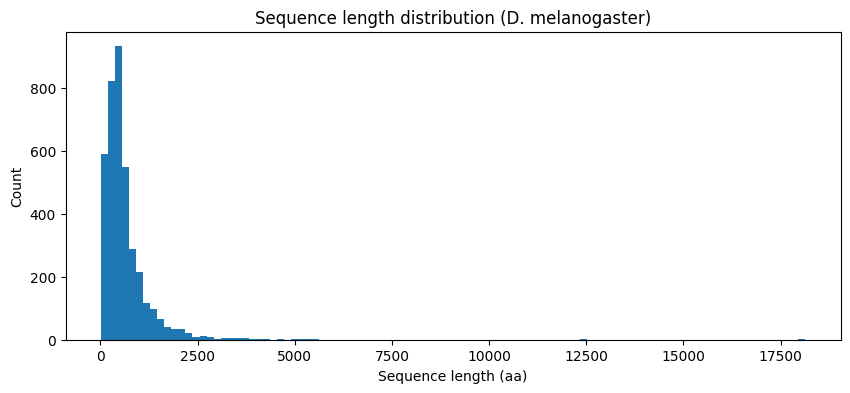

In [19]:
# Sequence length distribution
entries_df["seq_length"].plot.hist(
    bins=100,
    title="Sequence length distribution (D. melanogaster)",
    xlabel="Sequence length (aa)",
    ylabel="Count",
    figsize=(10, 4),
)

<Axes: title={'center': 'Annotation score distribution'}, xlabel='Annotation score', ylabel='Proteins'>

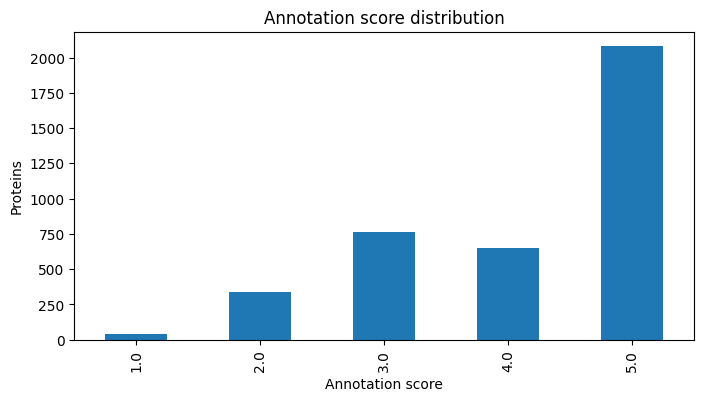

In [20]:
# Annotation score distribution
entries_df["annotation_score"].value_counts().sort_index().plot.bar(
    title="Annotation score distribution",
    xlabel="Annotation score",
    ylabel="Proteins",
    figsize=(8, 4),
)

## 5. PyArrow — file metadata and zero-copy reads

PyArrow gives you low-level access to Parquet metadata (row groups, compression, statistics) without reading the actual data.

In [21]:
import pyarrow.parquet as pq
import pyarrow.dataset as ds

# Inspect the entries Parquet file
entries_file = os.path.join(LAKE, "entries", "entries_00001.parquet")
meta = pq.read_metadata(entries_file)

print(f"Rows:        {meta.num_rows:,}")
print(f"Row groups:  {meta.num_row_groups}")
print(f"Columns:     {meta.num_columns}")
print(f"File size:   {os.path.getsize(entries_file) / 1024 / 1024:.1f} MB")
print(f"Created by:  {meta.created_by}")
print()

# Row group 0 statistics
rg = meta.row_group(0)
print(f"Row group 0: {rg.num_rows:,} rows")
print(f"\nColumn compression (first 10):")
for i in range(min(10, rg.num_columns)):
    col = rg.column(i)
    ratio = col.total_uncompressed_size / max(col.total_compressed_size, 1)
    print(f"  {col.path_in_schema:30s}  {col.compression:6s}  {ratio:.1f}x")

Rows:        3,868
Row groups:  1
Columns:     178
File size:   2.3 MB
Created by:  parquet-cpp-arrow version 23.0.1

Row group 0: 3,868 rows

Column compression (first 10):
  acc                             ZSTD    2.3x
  id                              ZSTD    2.6x
  reviewed                        ZSTD    8.4x
  secondary_accs.list.element     ZSTD    2.0x
  taxid                           ZSTD    0.8x
  organism_name                   ZSTD    0.9x
  organism_common                 ZSTD    0.8x
  lineage.list.element            ZSTD    162.1x
  gene_name                       ZSTD    1.7x
  gene_synonyms.list.element      ZSTD    1.6x


In [22]:
# PyArrow Dataset API — read with filters (pushdown)
entries_ds = ds.dataset(os.path.join(LAKE, "entries"), format="parquet")

# Read only acc + seq_length for proteins > 3000 aa
table = entries_ds.to_table(
    columns=["acc", "gene_name", "seq_length"],
    filter=ds.field("seq_length") > 3000,
)
print(f"{table.num_rows} proteins > 3000 aa")
table.to_pandas()

37 proteins > 3000 aa


,acc,gene_name,seq_length
0,A1Z713,Vps13,3321
1,A8DYP0,Obsc,4218
2,M9MRD1,Msp300,12345
3,M9NDE3,bark,3123
4,O15943,CadN,3097
5,P18490,pcx,3413
6,P20659,trx,3726
7,P28167,zfh2,3005
8,P33450,ft,5147
9,P37276,Dhc64C,4639


## 6. Analytical use cases

These queries demonstrate patterns that are impractical or impossible via UniProt's REST API — cross-proteome aggregations, positional analysis, and compositional profiling.

In [23]:
# Feature density per protein — which proteins are most annotated per amino acid?
con.sql("""
    SELECT
        acc,
        gene_name,
        seq_length,
        feature_count,
        round(feature_count * 1000.0 / seq_length, 1) AS features_per_1k_aa
    FROM entries
    WHERE seq_length > 100
    ORDER BY features_per_1k_aa DESC
    LIMIT 15
""").df()

,acc,gene_name,seq_length,feature_count,features_per_1k_aa
0,P02299,His3,136,39,286.8
1,P62152,Cam,149,41,275.2
2,P49258,Acam,148,37,250.0
3,Q9VWX8,Frq2,187,44,235.3
4,P84040,His4,103,24,233.0
5,P08879,awd,153,35,228.8
6,P10333,Acp26Aa,264,55,208.3
7,P47938,dhd,107,21,196.3
8,P00334,Adh,256,49,191.4
9,C0HL66,His3.3A,136,26,191.2


In [24]:
# Sequence composition — find cysteine-rich proteins
con.sql("""
    SELECT
        acc,
        gene_name,
        seq_length,
        length(sequence) - length(replace(sequence, 'C', '')) AS cysteine_count,
        round((length(sequence) - length(replace(sequence, 'C', ''))) * 100.0
              / seq_length, 1) AS cysteine_pct
    FROM entries
    WHERE seq_length > 50
    ORDER BY cysteine_pct DESC
    LIMIT 15
""").df()

,acc,gene_name,seq_length,cysteine_count,cysteine_pct
0,Q01644,Mst84Dc,55,22,40.0
1,P08175,Mst87F,56,21,37.5
2,Q01643,Mst84Db,74,27,36.5
3,Q01645,Mst84Dd,72,25,34.7
4,Q01642,Mst84Da,63,19,30.2
5,P02842,Sgs8,75,10,13.3
6,Q9W0A0,drpr,1031,134,13.0
7,O46202,Acp62F,115,14,12.2
8,P02841,Sgs7,74,9,12.2
9,P23487,mex1,83,10,12.0


In [25]:
# Feature coverage — what fraction of each protein is annotated?
con.sql("""
    WITH coverage AS (
        SELECT
            f.acc,
            e.gene_name,
            e.seq_length,
            sum(GREATEST(f.end_pos - f.start_pos + 1, 0)) AS annotated_aa
        FROM features f
        JOIN entries e ON e.acc = f.acc
        WHERE f.start_pos IS NOT NULL
          AND f.end_pos IS NOT NULL
          AND f.type NOT IN ('Chain', 'Modified residue')  -- exclude full-length features
        GROUP BY f.acc, e.gene_name, e.seq_length
    )
    SELECT
        acc,
        gene_name,
        seq_length,
        annotated_aa,
        round(annotated_aa * 100.0 / seq_length, 1) AS coverage_pct
    FROM coverage
    WHERE seq_length > 100
    ORDER BY coverage_pct DESC
    LIMIT 15
""").df()

,acc,gene_name,seq_length,annotated_aa,coverage_pct
0,Q86B87,mod(mdg4),610,7050.0,1155.7
1,Q86BJ3,pip,514,4741.0,922.4
2,Q8IRI6,Glut1,1440,9622.0,668.2
3,Q9VJY9,loqs,465,2769.0,595.5
4,Q9VML1,dsf,691,3852.0,557.5
5,Q8IQQ4,Gorab,338,1884.0,557.4
6,Q4LBB6,Octbeta3R,1256,6810.0,542.2
7,P10333,Acp26Aa,264,1182.0,447.7
8,Q9W0M1,Cep290,1978,8666.0,438.1
9,Q8MRC9,Pgant9,650,2818.0,433.5


In [26]:
# GO term enrichment — most common GO annotations
con.sql("""
    SELECT go_id, count(*) AS protein_count
    FROM (
        SELECT acc, unnest(go_ids) AS go_id
        FROM entries
        WHERE go_ids IS NOT NULL AND len(go_ids) > 0
    )
    GROUP BY go_id
    ORDER BY protein_count DESC
    LIMIT 20
""").df()

,go_id,protein_count
0,GO:0005634,1171
1,GO:0005737,930
2,GO:0005886,635
3,GO:0005829,537
4,GO:0005524,380
5,GO:0016020,366
6,GO:0008270,366
7,GO:0046872,310
8,GO:0006357,265
9,GO:0005739,263


In [27]:
# Keyword co-occurrence — which keywords appear together most often?
con.sql("""
    WITH kw AS (
        SELECT acc, unnest(keyword_names) AS keyword
        FROM entries
        WHERE keyword_names IS NOT NULL AND len(keyword_names) > 0
    )
    SELECT
        a.keyword AS keyword_1,
        b.keyword AS keyword_2,
        count(*) AS co_occurrences
    FROM kw a
    JOIN kw b ON a.acc = b.acc AND a.keyword < b.keyword
    GROUP BY keyword_1, keyword_2
    ORDER BY co_occurrences DESC
    LIMIT 15
""").df()

,keyword_1,keyword_2,co_occurrences
0,Membrane,Reference proteome,1105
1,Nucleus,Reference proteome,1078
2,Phosphoprotein,Reference proteome,881
3,Cytoplasm,Reference proteome,844
4,Metal-binding,Reference proteome,834
5,Alternative splicing,Reference proteome,781
6,Membrane,Transmembrane,779
7,Reference proteome,Transmembrane,777
8,Membrane,Transmembrane helix,775
9,Transmembrane,Transmembrane helix,775


In [28]:
# Publication timeline — when were these proteins characterised?
con.sql("""
    SELECT
        publication_date,
        count(*) AS citations
    FROM refs
    WHERE publication_date IS NOT NULL
    GROUP BY publication_date
    ORDER BY publication_date
""").df()

,publication_date,citations
0,1956,1
1,1969,2
2,1975,2
3,1978,1
4,1979,10
...,...,...
268,SEP-2010,3
269,SEP-2011,1
270,SEP-2012,3
271,SEP-2013,12


### Unnesting arrays and nested structures

Many columns in the lake are arrays (`VARCHAR[]`, `STRUCT[]`) or maps (`MAP(VARCHAR, VARCHAR)`). DuckDB's `unnest()` flattens these into rows, and `from_json()` parses JSON strings stored inside map values. This section shows common patterns.

In [29]:
# Unnest GO terms — one row per protein × GO ID
# (unnest in SELECT + GROUP BY requires a subquery)
con.sql("""
    SELECT go_id, count(DISTINCT acc) AS protein_count
    FROM (
        SELECT acc, unnest(go_ids) AS go_id
        FROM entries
        WHERE go_ids IS NOT NULL
    )
    GROUP BY go_id
    ORDER BY protein_count DESC
    LIMIT 15
""").df()

,go_id,protein_count
0,GO:0005634,1171
1,GO:0005737,930
2,GO:0005886,635
3,GO:0005829,537
4,GO:0005524,380
5,GO:0008270,366
6,GO:0016020,366
7,GO:0046872,310
8,GO:0006357,265
9,GO:0005739,263


In [30]:
# Unnest gene synonyms — find all aliases for each protein
con.sql("""
    SELECT acc, gene_name, unnest(gene_synonyms) AS synonym
    FROM entries
    WHERE gene_synonyms IS NOT NULL AND len(gene_synonyms) > 0
    LIMIT 15
""").df()

,acc,gene_name,synonym
0,A0A0B4K7J2,Nup358,RanBP2
1,A0A0B4K7K9,brp,Cast
2,A0A0B4K7K9,brp,nc82
3,A0A0B4KGY6,ps,l(3)10615
4,A0A0B4KGY6,ps,NOVA1
5,A0A0B7P9G0,uex,41Ad
6,A0A0B7P9G0,uex,GroupIII
7,A0A0B7P9G0,uex,l(2)41Ad
8,A0A1F4,eys,spam
9,A1Z6H7,Gp210,Gp188


In [31]:
# Unnest secondary accessions — trace merged/demerged UniProt entries
con.sql("""
    SELECT acc, gene_name, unnest(secondary_accs) AS old_acc
    FROM entries
    WHERE secondary_accs IS NOT NULL AND len(secondary_accs) > 0
    LIMIT 15
""").df()

,acc,gene_name,old_acc
0,A0A0B4K692,Nep2,D3DMK4
1,A0A0B4K692,Nep2,Q9XZ01
2,A0A0B4K7J2,Nup358,D3DMF2
3,A0A0B4K7J2,Nup358,Q8SWV7
4,A0A0B4K7J2,Nup358,Q9VBU7
5,A0A0B4K7K9,brp,A0A0B4K843
6,A0A0B4K7K9,brp,A1Z7V1
7,A0A0B4K7K9,brp,A8DY79
8,A0A0B4K7K9,brp,Q25B55
9,A0A0B4K859,Nup188,A1Z945


In [32]:
# Unnest cross-reference properties (struct array) with LATERAL join
# Each PDB xref has Method, Resolution, and Chains properties
con.sql("""
    SELECT x.acc, e.gene_name, x.id AS pdb_id, p.key, p.value
    FROM xrefs x
    JOIN entries e ON e.acc = x.acc,
    LATERAL unnest(x.properties) AS t(p)
    WHERE x.database = 'PDB'
      AND e.annotation_score = 5
    ORDER BY e.gene_name, x.id
    LIMIT 15
""").df()

,acc,gene_name,pdb_id,key,value
0,Q8IH18,4E-T,4UE9,Chains,B=9-44
1,Q8IH18,4E-T,4UE9,Resolution,2.15 A
2,Q8IH18,4E-T,4UE9,Method,X-ray
3,Q9VUQ5,AGO2,1R6Z,Method,X-ray
4,Q9VUQ5,AGO2,1R6Z,Resolution,2.80 A
5,Q9VUQ5,AGO2,1R6Z,Chains,A/P/Z=589-726
6,Q9VUQ5,AGO2,1T2R,Method,NMR
7,Q9VUQ5,AGO2,1T2R,Chains,A=602-720
8,Q9VUQ5,AGO2,1T2R,Resolution,-
9,Q9VUQ5,AGO2,1T2S,Resolution,-


In [33]:
# Unnest isoforms — the unnest_isoforms() macro parses JSON from the comment map
# Alpha-actinin (Actn) has 5 splice isoforms
con.sql("SELECT * FROM unnest_isoforms('P18091')").df()

,acc,gene_name,isoform_name,isoform_id,sequence_status,variant_sequence_ids
0,P18091,Actn,Long,P18091-1,Displayed,<NA>
1,P18091,Actn,Non-muscle,P18091-2,Described,"[VSP_000712, VSP_000714]"
2,P18091,Actn,Larval muscle,P18091-3,Described,[VSP_000716]
3,P18091,Actn,Adult muscle,P18091-4,Described,[VSP_000715]
4,P18091,Actn,A,P18091-5,Described,[VSP_000713]


In [34]:
# Proteome-wide isoform census — which proteins have the most splice variants?
con.sql("""
    WITH iso AS (
        SELECT
            acc,
            unnest(
                from_json(
                    element_at(comment, 'isoforms')[1]::JSON,
                    '[{"isoformIds":["VARCHAR"]}]'
                )
            ).isoformIds AS ids
        FROM comments
        WHERE comment_type = '"ALTERNATIVE PRODUCTS"'
    )
    SELECT i.acc, e.gene_name, len(i.ids) AS n_isoforms
    FROM iso i
    JOIN entries e ON e.acc = i.acc
    ORDER BY n_isoforms DESC
    LIMIT 15
""").df()

,acc,gene_name,n_isoforms
0,P12252,dnc,2
1,P53624,alpha-Man-Ia,2
2,P83949,Ubx,2
3,P83949,Ubx,2
4,P83292,Gr23a,2
5,P83949,Ubx,2
6,Q24522,bun,2
7,Q9W4S9,dnc,2
8,P51023,pnt,2
9,P83949,Ubx,2


## 7. Interoperability — zero-copy transfers

DuckDB, Polars, and pandas can exchange data through Apache Arrow with zero copies.

In [35]:
# DuckDB → Polars (zero-copy via Arrow)
arrow_table = con.sql("""
    SELECT acc, gene_name, protein_name, seq_length, go_ids
    FROM entries
    WHERE seq_length > 2000
    ORDER BY seq_length DESC
""").arrow()

polars_df = pl.from_arrow(arrow_table)
print(f"Zero-copy transfer: {len(polars_df)} rows from DuckDB → Polars")
polars_df.head()

Zero-copy transfer: 122 rows from DuckDB → Polars


acc,gene_name,protein_name,seq_length,go_ids
str,str,str,i32,list[str]
"""Q9I7U4""","""sls""","""Titin""",18141,"[""GO:0007525"", ""GO:0007062"", … ""GO:0031674""]"
"""M9MRD1""","""Msp300""","""Muscle-specific protein 300 kD…",12345,"[""GO:0007300"", ""GO:0051646"", … ""GO:0005737""]"
"""Q8SX83""","""spen""","""Protein split ends""",5560,"[""GO:0035222"", ""GO:0007379"", … ""GO:0005634""]"
"""Q9W596""","""futsch""","""Microtubule-associated protein…",5495,"[""GO:0008582"", ""GO:0031114"", … ""GO:0030425""]"
"""Q9VLT5""","""poe""","""Protein purity of essence""",5322,"[""GO:0007291"", ""GO:0032436"", … ""GO:0061630""]"


In [36]:
# DuckDB → pandas
pandas_df = con.sql("""
    SELECT acc, gene_name, seq_length, feature_count
    FROM entries
    ORDER BY feature_count DESC
    LIMIT 20
""").df()

pandas_df

,acc,gene_name,seq_length,feature_count
0,Q9I7U4,sls,18141,333
1,P07207,N,2703,281
2,O61307,Ten-m,2731,230
3,P13368,sev,2554,218
4,A1ZAW0,Dcr-2,1722,204
5,Q9W596,futsch,5495,202
6,Q0E9H9,Dscam1,2016,195
7,Q9VCU9,Dcr-1,2249,187
8,Q8SX83,spen,5560,173
9,Q00174,LanA,3712,170


In [37]:
# Export to CSV via DuckDB
csv_path = os.path.join(os.getcwd(), "drosophila_kinases.csv")
con.sql(f"""
    COPY (
        SELECT acc, gene_name, protein_name, seq_length, ec_numbers
        FROM entries
        WHERE list_contains(keyword_names, 'Kinase')
        ORDER BY gene_name
    ) TO '{csv_path}' (HEADER, DELIMITER ',')
""")

# Verify
result = pd.read_csv(csv_path)
print(f"Exported {len(result)} kinases to {csv_path}")
result.head(10)

Exported 138 kinases to /Users/dlrice/Developer/uniprot-parquet/demo/drosophila_kinases.csv


,acc,gene_name,protein_name,seq_length,ec_numbers
0,P00522,Abl,Tyrosine-protein kinase Abl,1620,[2.7.10.2]
1,Q9VZI2,Ack,Activated Cdc42 kinase Ack,1073,"[2.7.10.2, 2.7.11.1]"
2,Q9I7F7,Ack-like,Activated Cdc42 kinase-like,1337,[2.7.10.2]
3,Q9W133,Adck1,AarF domain-containing kinase 1,518,[2.7.-.-]
4,Q8IQG9,Ak1,Adenylate kinase 1,229,[2.7.4.3]
5,Q9U915,Ak2,Adenylate kinase 2,240,[2.7.4.3]
6,Q9VGU6,Ak3,"GTP:AMP phosphotransferase, mitochondrial",216,[2.7.4.10]
7,Q7JYV7,Ak6,Adenylate kinase isoenzyme 6 homolog,175,[2.7.4.3]
8,Q8INB9,Akt,RAC serine/threonine-protein kinase,611,[2.7.11.1]
9,P48610,Argk1,Arginine kinase 1,356,[2.7.3.3]


## 8. Accessing nested structures

Every table preserves the full original UniProtKB JSON as nested DuckDB structs. This means no data is ever discarded — if the convenience columns aren't enough, you can always reach into the nested structures.

In [38]:
# Access the full nested organism struct
con.sql("""
    SELECT
        acc,
        organism.scientificName AS scientific_name,
        organism.commonName AS common_name,
        organism.taxonId AS taxon_id,
        organism.lineage AS lineage
    FROM entries
    LIMIT 3
""").df()

,acc,scientific_name,common_name,taxon_id,lineage
0,A0A0B4K692,Drosophila melanogaster,Fruit fly,7227,"[Eukaryota, Metazoa, Ecdysozoa, Arthropoda, He..."
1,A0A0B4K753,Drosophila melanogaster,Fruit fly,7227,"[Eukaryota, Metazoa, Ecdysozoa, Arthropoda, He..."
2,A0A0B4K7J2,Drosophila melanogaster,Fruit fly,7227,"[Eukaryota, Metazoa, Ecdysozoa, Arthropoda, He..."


In [39]:
# Access the full nested feature struct (includes evidence codes, cross-references)
con.sql("""
    SELECT
        acc,
        feature.type AS type,
        feature.description AS description,
        feature.location.start.value AS start_pos,
        feature.location.end.value AS end_pos,
        feature.evidences AS evidences
    FROM features
    WHERE acc = 'P07207'  -- Notch
    LIMIT 10
""").df()

,acc,type,description,start_pos,end_pos,evidences
0,P07207,Signal,,1,52,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
1,P07207,Sequence conflict,in Ref. 5; CAB37610,9,9,"[{'evidenceCode': 'ECO:0000305', 'source': Non..."
2,P07207,Chain,Neurogenic locus Notch protein,53,2703,<NA>
3,P07207,Topological domain,Extracellular,53,1745,"[{'evidenceCode': 'ECO:0000255', 'source': Non..."
4,P07207,Domain,EGF-like 1,58,95,"[{'evidenceCode': 'ECO:0000255', 'source': 'PR..."
5,P07207,Disulfide bond,,62,73,"[{'evidenceCode': 'ECO:0000255', 'source': 'PR..."
6,P07207,Disulfide bond,,67,83,"[{'evidenceCode': 'ECO:0000255', 'source': 'PR..."
7,P07207,Glycosylation,O-linked (Fuc...) threonine,72,72,"[{'evidenceCode': 'ECO:0000269', 'source': 'Pu..."
8,P07207,Sequence conflict,in Ref. 5; CAB37610,84,84,"[{'evidenceCode': 'ECO:0000305', 'source': Non..."
9,P07207,Disulfide bond,,85,94,"[{'evidenceCode': 'ECO:0000255', 'source': 'PR..."


In [40]:
# Access the full nested comment struct (polymorphic — varies by comment type)
con.sql("""
    SELECT
        acc,
        comment.commentType AS type,
        comment.texts AS texts,
        comment.subcellularLocations AS subcellular_locations
    FROM comments
    WHERE acc = 'P07207'  -- Notch
""").df()

,acc,type,texts,subcellular_locations
0,P07207,"""DEVELOPMENTAL STAGE""","[{""evidences"":[{""evidenceCode"":""ECO:0000269"",""...",None
1,P07207,"""DISRUPTION PHENOTYPE""","[{""evidences"":[{""evidenceCode"":""ECO:0000269"",""...",None
2,P07207,"""DOMAIN""","[{""evidences"":[{""evidenceCode"":""ECO:0000269"",""...",None
3,P07207,"""FUNCTION""","[{""evidences"":[{""evidenceCode"":""ECO:0000269"",""...",None
4,P07207,"""INTERACTION""",None,None
5,P07207,"""PTM""","[{""value"":""Upon binding its ligands such as De...",None
6,P07207,"""PTM""","[{""evidences"":[{""evidenceCode"":""ECO:0000269"",""...",None
7,P07207,"""PTM""","[{""evidences"":[{""evidenceCode"":""ECO:0000269"",""...",None
8,P07207,"""SIMILARITY""","[{""evidences"":[{""evidenceCode"":""ECO:0000305""}]...",None
9,P07207,"""SUBCELLULAR LOCATION""",None,"[{""location"":{""evidences"":[{""evidenceCode"":""EC..."


---

**Summary**: This data lake approach enables millisecond analytical queries that are impractical via UniProt's REST API — cross-proteome aggregations, compositional analysis, positional interval queries, keyword co-occurrence, and publication timelines. The same Parquet files work with DuckDB (SQL), Polars (lazy DataFrames), pandas, and PyArrow, with zero-copy Arrow transfers between them.